# Model to forecast churning (clients leaving) for Telco Industry

Begin by importing the libraries required for the task

In [29]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

I am importing the data from the csv file Telco-Customer-Churn

In [30]:
tele_df = pd.read_csv('Telco-Customer-Churn.csv')
tele_df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


From looking at the top 10 rows above and the data types of the columns below we can see:

A) Columns such as MultipleLines have some fields where the data needs updating. "No phone service" is the same as "No"

B) The fields containing numerical data are correctly classified as integer/float data types except TotalCharges

This is because the TotalCharges field has some blank fields where tenure = 0 as the clients haven't paid a bill yet

When importing csv data blank fields sometimes have a space so I have stripped that out and updated the blank

fields to nulls, so TotalCharges now has 11 null values in it.

In [31]:
tele_df = tele_df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)
tele_df = tele_df.replace("", np.nan)
tele_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

The fields where TotalCharge is blank is  when tenure is zero as the clients haven't 

paid their first bill yet. I am going to drop these rows from the table.

We now have 7032 rows of data in the dataset and I am updating the data type

for the TotalCharges field to being a float.

In [32]:
tele_df = tele_df.dropna(subset=['TotalCharges'])
tele_df['TotalCharges'] = pd.to_numeric(tele_df['TotalCharges'], errors='coerce')
tele_df = tele_df.dropna(subset=['TotalCharges'])
tele_df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

Next I am replacing cells that say "No phone serivice" with "No" as it's the same result.

I am also replacing any fields with "No internet service" with "No" as they are also the same thing.

In [33]:
tele_df.loc[tele_df['MultipleLines'] == 'No phone service', 'MultipleLines'] = 'No'

Update_List = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

for i in Update_List:
    tele_df.loc[tele_df[i] == 'No internet service', i] = 'No'

Below I am checking for duplicate rows in the data set and we can see there aren't any.

In [34]:
duplicate_rows = tele_df[tele_df.duplicated()]
print("\nDuplicate rows:\n", duplicate_rows)


Duplicate rows:
 Empty DataFrame
Columns: [customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []

[0 rows x 21 columns]


As customerID is not going to be a useful feature for training our model

I am dropping it from the dataset

In [35]:
tele_df.drop(["customerID"], axis=1, inplace=True)

I am now applying one-hot encoding to the non numerical fields so 

they can be used in the predictive model and creating a new dataframe

called telecom_cust_dummies.

In [36]:
telecom_cust_dummies = tele_df.copy()
telecom_cust_dummies = pd.get_dummies(telecom_cust_dummies, prefix="Churn", columns=["Churn"],dtype=int)
text_cols = (telecom_cust_dummies.select_dtypes(include=['str']).columns
             .tolist())
for i in text_cols:
    telecom_cust_dummies = pd.get_dummies(telecom_cust_dummies, prefix=i, columns=[i],drop_first=True,dtype=int)
telecom_cust_dummies.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_No,Churn_Yes,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,1,0,0,1,...,1,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,0,1,1,0,0,1,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,1,0,0,0,...,1,1,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,1,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0


Below you can see how the features correlate with client churn.

The most positive correlations are between Churn and if a client has

fibre optic cable which implies this isn't a popular service of theres.

At the other end the tenure has the greatest negative correlation to churn

as the longer the client has been there the less likely they are to leave.

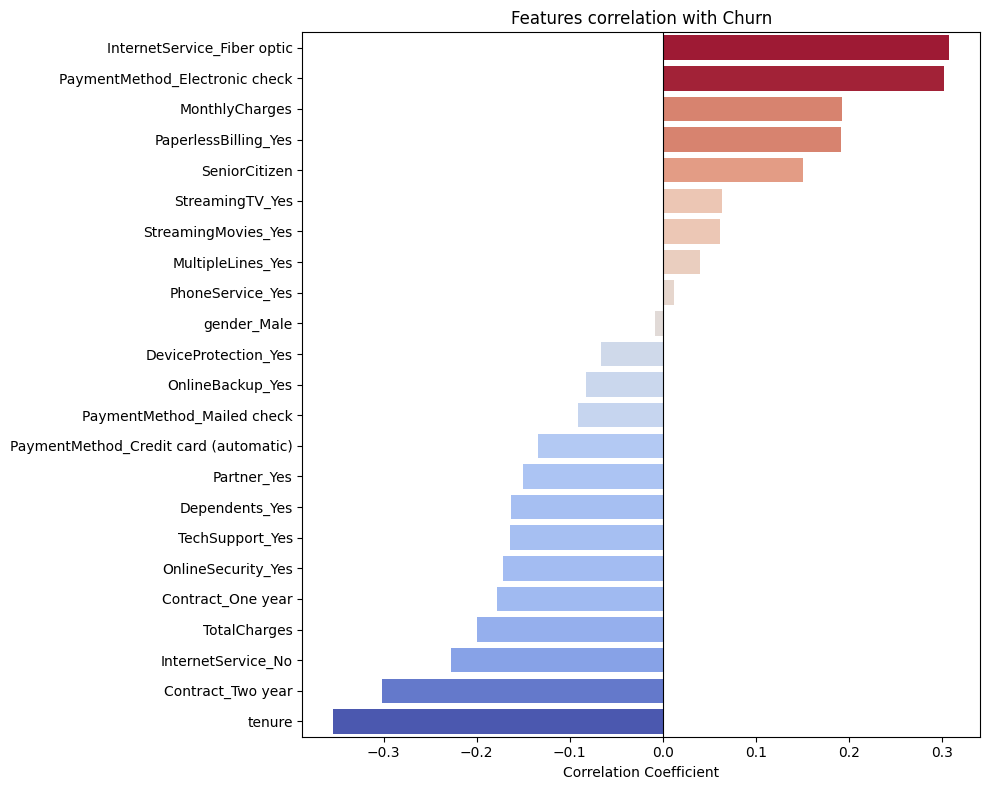

In [37]:
corr = telecom_cust_dummies.corr()['Churn_Yes'].drop(['Churn_Yes','Churn_No']).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=corr.values, y=corr.index, hue=corr.values, palette='coolwarm', legend=False)
plt.title('Features correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.ylabel('')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Creating a histogram of the Tenure data we can see that the clients are largely in 2 camps

New clients that have only been there a few months or have been there over 70 months.

The large number of clients with lower tenures shows:

A) That a lot of the clients that leave, do so quickly.

B) They have had a successful sales drive recently, so have a lot of new joining clients.

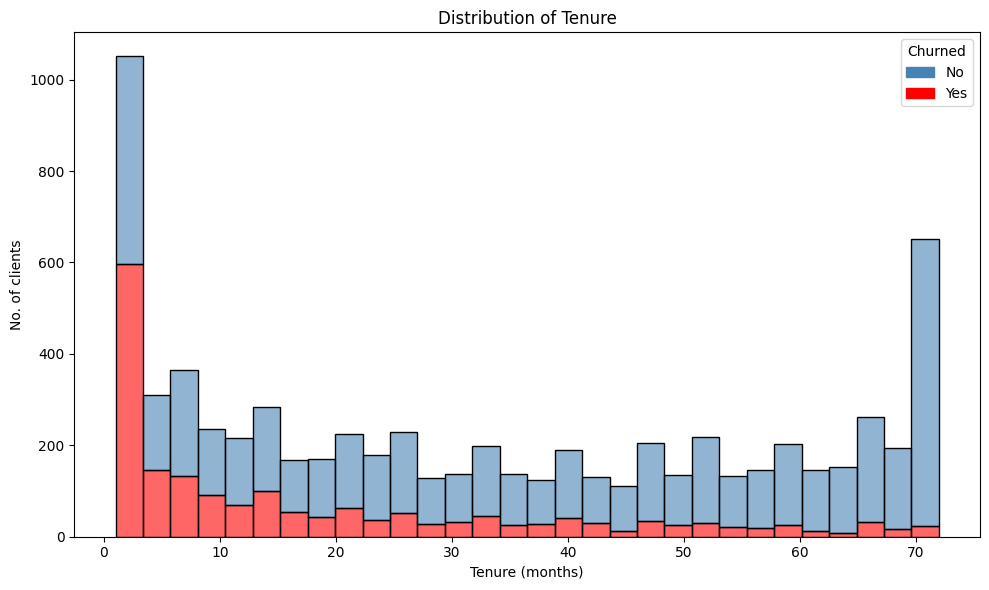

In [38]:
plt.figure(figsize=(10, 6))
sns.histplot(data=telecom_cust_dummies, x='tenure', bins=30, 
             hue='Churn_Yes', palette={0: 'steelblue', 1: 'red'}, alpha=0.6, multiple='stack')
plt.title('Distribution of Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('No. of clients')

handles = [
    mpatches.Patch(color='steelblue', label='No'),
    mpatches.Patch(color='red', label='Yes')
]
plt.legend(handles=handles, title='Churned')
plt.tight_layout()
plt.show()

The positive correlation between the Monthly Charges and Total Charges below

makes sense as if all clients stay with the company for similar time frames

the ones paying the larger monthly fees will accrue the greatest overall total charges.

The colour coding below, again, shows that the majority of the clients that have left (Churned)

have low total charges overall as they must have left after a brief period of time.

If a client stays past a year their probability of leaving drops significantly.

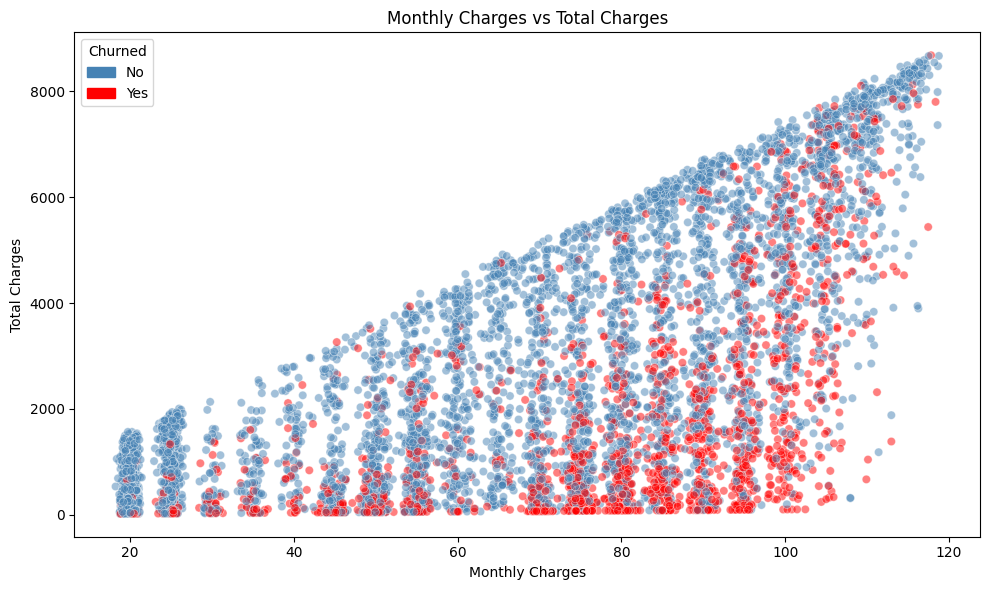

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=telecom_cust_dummies, x='MonthlyCharges', y='TotalCharges', 
                hue='Churn_Yes', palette={0: 'steelblue', 1: 'red'}, alpha=0.5)
plt.title('Monthly Charges vs Total Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')

handles = [
    mpatches.Patch(color='steelblue', label='No'),
    mpatches.Patch(color='red', label='Yes')
]
plt.legend(handles=handles, title='Churned')
plt.tight_layout()
plt.show()

Charting the tenure vs Churning status of the client confirms the fact that

the majority of the clients that left, did so after a brief period of time

although there are some outliers that did for over 60 months.

Clients that have stayed have done so by and large for a long

period of time.

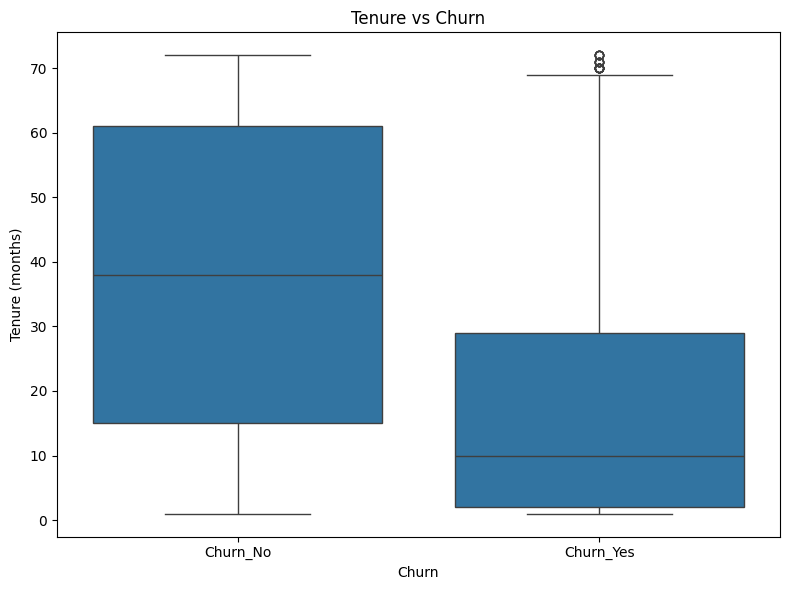

In [40]:
churn_melted = telecom_cust_dummies.melt(value_vars=['Churn_No', 'Churn_Yes'], 
                                          id_vars='tenure', 
                                          var_name='Churn', 
                                          value_name='value')

plt.figure(figsize=(8, 6))
sns.boxplot(data=churn_melted[churn_melted['value'] == 1], x='Churn', y='tenure')
plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (months)')
plt.tight_layout()
plt.show()

In order to prepare the data for training I have defined the features (independent variables X)

and the dependent variable y we are looking to predict "Churn" value "Yes".

In [41]:
X = telecom_cust_dummies.drop(columns=['Churn_Yes','Churn_No'])
y = telecom_cust_dummies['Churn_Yes']
X.shape

feature_names = X.columns
feature_names

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year',
       'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

I have chosen a random state seed value of 42 to ensure that each test run

generates the same results and split the data 75% to training, 25% for testing.

In [42]:
r = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=r)

Given that the features all have different scales I am using a Min/Max scaler to normalize the data

so they their values are between 0 and 1. Without rescaling the model could give greater weight

to the features with higher values in their dataset.

In [43]:
sc = MinMaxScaler()
sc.fit(X_train)

X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

Now the data has been rescaled the the variables need to be fitted to a model.

Below I am using a linear regression model and then generating predictions

using the test data.


In [44]:
# Fit a model
lm = LogisticRegression()
model = lm.fit(X_train, y_train)
predictions = lm.predict(X_test)

# Create line coordinates
X_line = np.empty(X_test.shape)
for i in range(X_test.shape[1]):
    X_line[:, i] = np.linspace(np.min(X_test[:,i]), np.max(X_test[:,i]), num=X_test.shape[0])
y_line = lm.predict(X_line)

print('Intercept: \n', lm.intercept_)
print('Coefficients: \n', lm.coef_)

Intercept: 
 [-0.06279051]
Coefficients: 
 [[ 0.24237577 -3.29529537  0.14589982  1.39733047 -0.03165163  0.08627573
  -0.25106732 -0.55390192  0.19783191  0.84973862 -0.69653893 -0.42640608
  -0.11677138  0.01505259 -0.36923243  0.21830759  0.26517317 -0.78423768
  -1.32561234  0.23168137 -0.12910509  0.26653017 -0.05137   ]]


As we are using a Logistic Regression model its predictions are binary outcomes.

In [45]:
predictions[0:5]

array([0, 0, 1, 0, 0])

Now we have generated predictions for the model we can calculate the R2 score

to determine the effectiveness of the predictions. With the scores ranging from 0-1

a score of 0.7912 which fairly decent for a a predictive model.

In [46]:
print ("R2 Score:", round(model.score(X_test, y_test), 4))

R2 Score: 0.7912


Using a Random Forest Classifier we can create a model.

I have applied to the model:

Using oob_score means each tree in the forest is trained on a random bootstrap.

The remaining data not used in training is used to test the model which give the OOB score.

The OOB error estimation means that the model is misclassifying 19.5% of the OOB samples

which is a relatively similar level of error to the Logistic Regression model.

In [47]:
# Create Random Forest Classifier
rf = RandomForestClassifier(n_estimators=2000, oob_score=True,
                            max_features='sqrt', bootstrap=True, random_state=r, max_leaf_nodes = 50)

# Train the RF classifier
rf.fit(X_train,y_train)

#Predict the response for test dataset for the models
y_test_pred_rf = rf.predict(X_test)

print(f'Testing Accuracy for Random Forest model: {(accuracy_score(y_test, y_test_pred_rf)):2f}')
print(f'OOB Error Estimation: {1- rf.oob_score_:2f}')

Testing Accuracy for Random Forest model: 0.795222
OOB Error Estimation: 0.194539


Below is are a pair of Confusion Matrices for the Logistic Regression and 

Random Forest Model. Seeing the breakdown shows the underlying differences

between the two which have very similar looking accuracy scores.

The Logistic Regression model appears to perform better than the Random Forest

in identifying clients that left with a higher number of True Positives,

but fares worse in accurately identifying clients that are still customers

with it's lower True Negative score.

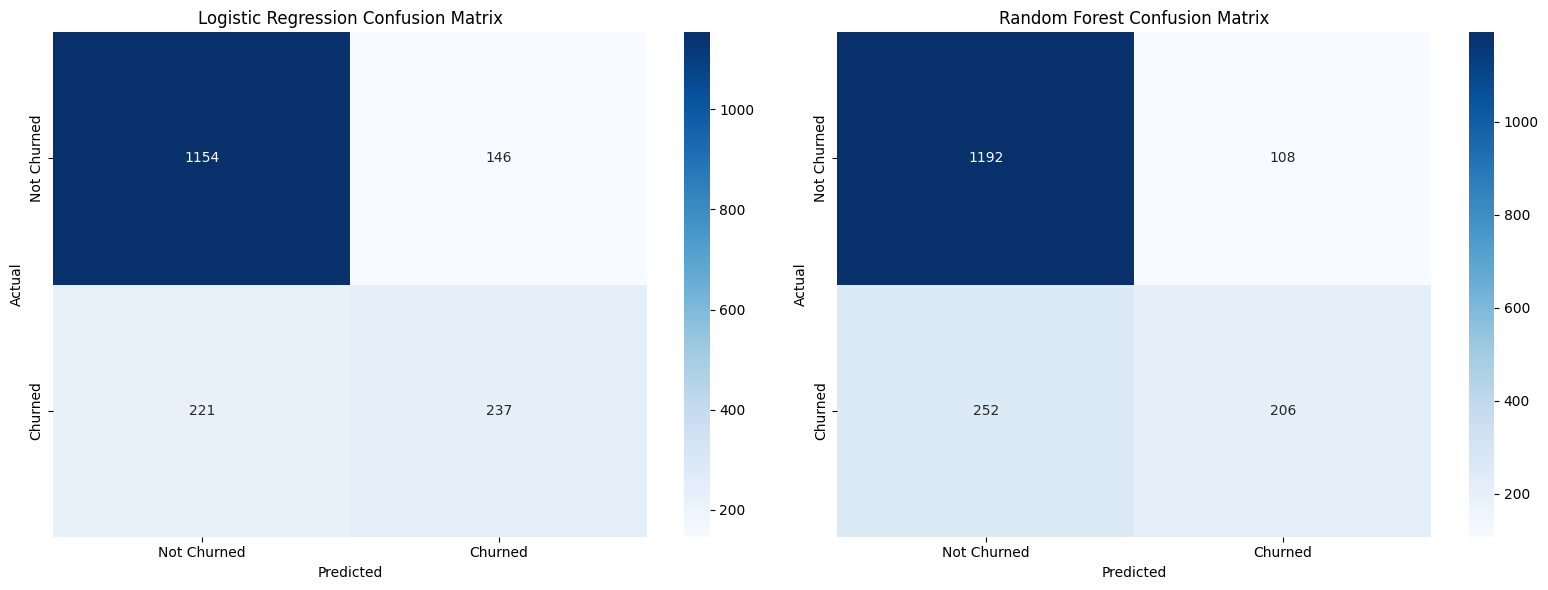

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_lr = confusion_matrix(y_test, predictions)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Random Forest
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

The Logistic Regression model had an accuracy of 0.7912.

The Random Forest Model had an accuracy of 0.7952 which is fractionally higher.

Looking at the Precision and Recall figures shows that the Random Forest wasn't

better in every dimension.

For Logistic Regression:

Precision = 237/(237+221) = 0.517

Recall = 237/(237+147) = 0.617

For the Random Forest Model:

Precision = 206/(206+252) = 0.450

Recall = 206/(206+108) = 0.656

Precision is the proportion of predictions of the positive class that is correct

E.g. of the customers that the model predicted were Churners, how many actually were.

The Logistic Regression model proved better at identifying the Churned customers 

with a score of 0.517 vs 0.45

Recall is the measure of for the actual Churners how many did we capture.

The Random Forest model performed better on this with a recall score of 0.656 vs 0.617

While both models have positives in different areas the Random Forests superior performance

in Recall is more useful for Telco as it missed fewer genuine leavers than 

the Logistic Regression model.